# CardioAI Fase 2 - Classificação de risco clínico

Este notebook executa a Parte 2 do Desafio Integrador: valida o dataset sintético, transforma relatos com TF-IDF, compara três classificadores e avalia o modelo selecionado em um conjunto de teste estratificado. A solução é educacional e não substitui avaliação médica.

## 1. Preparação e reprodutibilidade

A semente é fixa em 42. O TF-IDF fica dentro de um `Pipeline`, evitando que o vocabulário do teste seja usado durante o treinamento.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

RAIZ = Path.cwd()
if not (RAIZ / 'src').exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / 'src'))

from cardioai.classificador import carregar_dataset, treinar_e_avaliar

pd.set_option('display.max_colwidth', 120)

mkdir -p failed for path C:\Users\win\AppData\Local\matplotlib: [WinError 5] Acesso negado: 'C:\\Users\\win\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\win\AppData\Local\Temp\matplotlib-e4qg3tva because there was an issue with the default path (C:\Users\win\AppData\Local\matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Dataset sintético

Os relatos são exemplos fictícios e não contêm dados pessoais. Os rótulos representam somente uma simulação binária de priorização.

In [2]:
caminho_dados = RAIZ / 'src' / 'database' / 'relatos_risco.csv'
dados = carregar_dataset(caminho_dados)
print(f'Registros: {len(dados)}')
display(dados.head())
display(dados['situacao'].value_counts().rename('quantidade').to_frame())

Registros: 60


,frase,situacao
0,Sinto pressão forte no peito e falta de ar mesmo estando sentado,alto_risco
1,A dor no peito começou de repente e está irradiando para o braço esquerdo,alto_risco
2,Meu coração está disparado e quase desmaiei ao levantar,alto_risco
3,Estou com dor intensa no peito acompanhada de suor frio e enjoo,alto_risco
4,Acordei sem conseguir respirar e só melhoro quando fico sentado,alto_risco


,quantidade
situacao,
alto_risco,30
baixo_risco,30


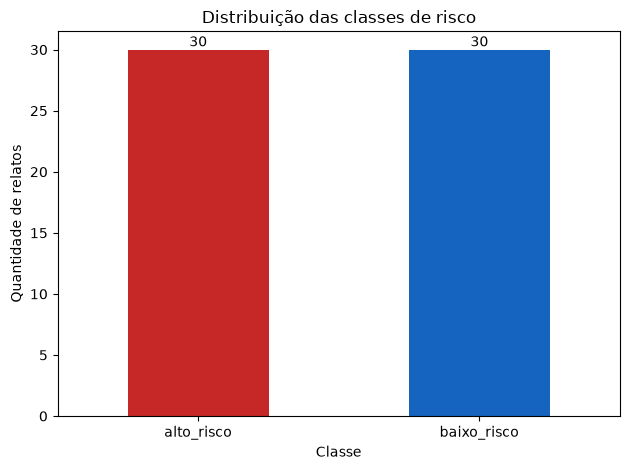

In [3]:
ax = dados['situacao'].value_counts().sort_index().plot.bar(
    color=['#c62828', '#1565c0'], title='Distribuição das classes de risco'
)
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade de relatos')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. TF-IDF, validação cruzada e seleção do modelo

A comparação usa cinco partições estratificadas apenas no conjunto de treinamento. O modelo é ordenado primeiro pelo recall de `alto_risco`, depois por F1 macro e acurácia.

In [4]:
resultado = treinar_e_avaliar(dados)
display(resultado.comparacao_cv.style.format({
    'acuracia': '{:.3f}',
    'precisao_alto': '{:.3f}',
    'recall_alto': '{:.3f}',
    'f1_macro': '{:.3f}',
}))
print(f'Modelo selecionado: {resultado.modelo_nome}')

,modelo,acuracia,precisao_alto,recall_alto,f1_macro
0,Naive Bayes Complementar,0.753,0.696,0.880,0.749
1,Regressão Logística,0.771,0.743,0.840,0.769
2,SVM Linear,0.729,0.700,0.790,0.728


Modelo selecionado: Naive Bayes Complementar


## 4. Avaliação no conjunto de teste

O teste contém 20% da base e preserva a proporção das duas classes. A matriz segue a ordem `baixo_risco`, `alto_risco`.

,valor
acuracia,0.917
precisao_alto_risco,1.000
recall_alto_risco,0.833
f1_alto_risco,0.909


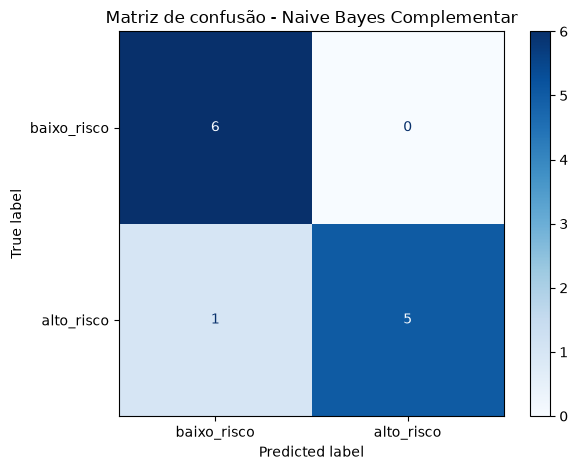

In [5]:
metricas = pd.Series(resultado.metricas_teste, name='valor').to_frame()
display(metricas.style.format('{:.3f}'))

ConfusionMatrixDisplay(
    confusion_matrix=pd.DataFrame(resultado.matriz_confusao).to_numpy(),
    display_labels=['baixo_risco', 'alto_risco'],
).plot(cmap='Blues', values_format='d')
plt.title(f'Matriz de confusão - {resultado.modelo_nome}')
plt.tight_layout()
plt.show()

In [6]:
analise_erros = pd.DataFrame({
    'frase': resultado.frases_teste,
    'real': resultado.y_teste,
    'previsto': resultado.y_previsto,
})
analise_erros['correto'] = analise_erros['real'] == analise_erros['previsto']
display(analise_erros.sort_values('correto'))
print(f'Erros no teste: {(~analise_erros["correto"]).sum()} de {len(analise_erros)}')

,frase,real,previsto,correto
6,Desmaiei depois de sentir o coração bater de forma irregular,alto_risco,baixo_risco,False
10,Meu peito começou a doer durante a madrugada e estou suando frio,alto_risco,alto_risco,True
58,Sinto azia ocasional depois de café e não tenho sintomas durante esforço,baixo_risco,baixo_risco,True
44,Tenho uma dor muscular no peito que aparece quando pressiono o local,baixo_risco,baixo_risco,True
45,Senti o coração acelerar após correr mas voltou ao normal em poucos minutos,baixo_risco,baixo_risco,True
14,Meu ritmo cardíaco está descompassado e minha visão escureceu,alto_risco,alto_risco,True
39,Estou com coriza tosse leve e indisposição desde ontem,baixo_risco,baixo_risco,True
7,Sinto um aperto no tórax sempre que caminho poucos metros,alto_risco,alto_risco,True
55,Tenho desconforto no ombro após dormir em posição ruim,baixo_risco,baixo_risco,True
19,O coração acelera de repente e sinto que vou apagar,alto_risco,alto_risco,True


Erros no teste: 1 de 12


## 5. Vieses, distorções e limitações

- A base é pequena, sintética e escrita pelo próprio grupo; as métricas não estimam desempenho clínico real.
- As classes `baixo_risco` e `alto_risco` estão balanceadas por construção. Isso facilita o experimento, mas não representa a prevalência real.
- Certas palavras podem funcionar como atalhos, como 'desmaio' e 'leve'. A análise de erros deve observar dependência excessiva desses termos.
- Localização, idade, sexo e outros dados pessoais foram excluídos deliberadamente para reduzir reidentificação e atalhos demográficos. Essa decisão também impede medir disparidades entre grupos demográficos.
- Falsos negativos de `alto_risco` são o erro mais preocupante. Por isso, o recall dessa classe orienta a seleção, sem ocultar precisão, F1 e matriz de confusão.
- Antes de qualquer aplicação real seriam necessários dados clínicos representativos, validação externa, supervisão médica, governança e monitoramento contínuo.

## 6. Conclusão

O experimento demonstra o fluxo técnico solicitado, mas não produz diagnóstico médico. Os resultados devem ser lidos como evidência de funcionamento sobre esta amostra sintética específica.